In [3]:
import cv2
import tensorflow as tf
import pandas as pd
import numpy as np
from deepface import DeepFace
print("All imports are successful. All libraries are installed and working properly.")


All imports are successful. All libraries are installed and working properly.


In [4]:
from sklearn.datasets import fetch_lfw_people

In [5]:
from pathlib import Path

DATASET_PATH = Path("../datasets/lfw")

print(DATASET_PATH.exists())

True


In [6]:
people = sorted(
    [
        person
        for person in DATASET_PATH.iterdir()
        if person.is_dir()
    ]
)

print("Total people :", len(people))

Total people : 5749


In [7]:
people[:10]

[WindowsPath('../datasets/lfw/Aaron_Eckhart'),
 WindowsPath('../datasets/lfw/Aaron_Guiel'),
 WindowsPath('../datasets/lfw/Aaron_Patterson'),
 WindowsPath('../datasets/lfw/Aaron_Peirsol'),
 WindowsPath('../datasets/lfw/Aaron_Pena'),
 WindowsPath('../datasets/lfw/Aaron_Sorkin'),
 WindowsPath('../datasets/lfw/Aaron_Tippin'),
 WindowsPath('../datasets/lfw/Abba_Eban'),
 WindowsPath('../datasets/lfw/Abbas_Kiarostami'),
 WindowsPath('../datasets/lfw/Abdel_Aziz_Al-Hakim')]

In [8]:
person_image_count = {}

for person in people:

    images = list(person.glob("*.jpg"))

    person_image_count[person.name] = len(images)

In [9]:
list(person_image_count.items())[:10]

[('Aaron_Eckhart', 1),
 ('Aaron_Guiel', 1),
 ('Aaron_Patterson', 1),
 ('Aaron_Peirsol', 4),
 ('Aaron_Pena', 1),
 ('Aaron_Sorkin', 2),
 ('Aaron_Tippin', 1),
 ('Abba_Eban', 1),
 ('Abbas_Kiarostami', 1),
 ('Abdel_Aziz_Al-Hakim', 1)]

In [10]:
MIN_IMAGES = 20

eligible_people = {
    name: count
    for name, count in person_image_count.items()
    if count >= MIN_IMAGES
}

print("Eligible people:", len(eligible_people))

Eligible people: 62


In [11]:
eligible_people

{'Alejandro_Toledo': 39,
 'Alvaro_Uribe': 35,
 'Amelie_Mauresmo': 21,
 'Andre_Agassi': 36,
 'Angelina_Jolie': 20,
 'Ariel_Sharon': 77,
 'Arnold_Schwarzenegger': 42,
 'Atal_Bihari_Vajpayee': 24,
 'Bill_Clinton': 29,
 'Carlos_Menem': 21,
 'Colin_Powell': 236,
 'David_Beckham': 31,
 'Donald_Rumsfeld': 121,
 'George_Robertson': 22,
 'George_W_Bush': 530,
 'Gerhard_Schroeder': 109,
 'Gloria_Macapagal_Arroyo': 44,
 'Gray_Davis': 26,
 'Guillermo_Coria': 30,
 'Hamid_Karzai': 22,
 'Hans_Blix': 39,
 'Hugo_Chavez': 71,
 'Igor_Ivanov': 20,
 'Jack_Straw': 28,
 'Jacques_Chirac': 52,
 'Jean_Chretien': 55,
 'Jennifer_Aniston': 21,
 'Jennifer_Capriati': 42,
 'Jennifer_Lopez': 21,
 'Jeremy_Greenstock': 24,
 'Jiang_Zemin': 20,
 'John_Ashcroft': 53,
 'John_Negroponte': 31,
 'Jose_Maria_Aznar': 23,
 'Juan_Carlos_Ferrero': 28,
 'Junichiro_Koizumi': 60,
 'Kofi_Annan': 32,
 'Laura_Bush': 41,
 'Lindsay_Davenport': 22,
 'Lleyton_Hewitt': 41,
 'Luiz_Inacio_Lula_da_Silva': 48,
 'Mahmoud_Abbas': 29,
 'Megawati_Suk

In [12]:
from pathlib import Path
import cv2

IMAGE_SIZE = (224, 224)

images = []
labels = []

In [13]:
for person_name in eligible_people.keys():

    person_folder = DATASET_PATH / person_name

    for image_path in person_folder.glob("*.jpg"):

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, IMAGE_SIZE)

        images.append(image)
        labels.append(person_name)

In [14]:
print("Images loaded :", len(images))
print("Labels loaded :", len(labels))

Images loaded : 3023
Labels loaded : 3023


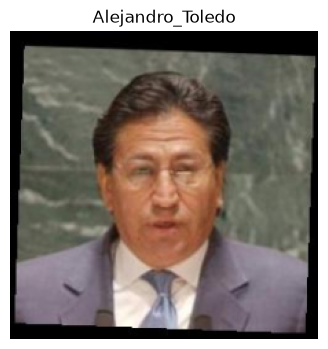

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(images[0])
plt.title(labels[0])
plt.axis("off")
plt.show()

In [16]:
print(type(images[0]))
print(images[0].shape)

<class 'numpy.ndarray'>
(224, 224, 3)


In [17]:
from deepface import DeepFace

In [39]:
embedding_vectors = []
embedding_labels = []

In [19]:
from deepface import DeepFace

In [40]:
from tqdm import tqdm

In [20]:
import deepface
print(deepface.__version__)

0.0.93


In [21]:
from deepface.modules import modeling

print(hasattr(modeling, "build_model"))

True


In [ ]:
# TEST_IMAGES = 10

In [26]:
from deepface import DeepFace

DeepFace.represent(
    img_path=images[0],
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)

[{'embedding': [2.872398853302002,
   1.8365398645401,
   -0.08463871479034424,
   -0.09010416269302368,
   0.27377524971961975,
   -0.8264031410217285,
   -1.2321876287460327,
   1.1504484415054321,
   0.13555091619491577,
   -0.28385141491889954,
   -1.012380838394165,
   -1.7408610582351685,
   0.268659383058548,
   -0.02679252251982689,
   0.3996064364910126,
   -0.04842282086610794,
   -0.49329572916030884,
   -0.8021049499511719,
   0.3823702335357666,
   0.041942864656448364,
   0.8830235600471497,
   -0.19080659747123718,
   -1.361106514930725,
   0.5723358392715454,
   1.0595365762710571,
   -0.8684382438659668,
   1.7582449913024902,
   0.04342598840594292,
   0.2302745133638382,
   -0.30171269178390503,
   1.644176721572876,
   0.3337319493293762,
   0.9862746596336365,
   0.009179985150694847,
   0.15478654205799103,
   -1.5079060792922974,
   0.42247912287712097,
   0.9341443777084351,
   1.036342978477478,
   -2.7433860301971436,
   -2.165220022201538,
   -0.3162446320056

In [41]:
embedding_vectors = []
embedding_labels = []

for image, label in tqdm(zip(images, labels), total=len(images)):

    try:

        embedding = DeepFace.represent(
            img_path=image,
            model_name="Facenet512",
            detector_backend="mtcnn",
            enforce_detection=False
        )[0]["embedding"]

        embedding_vectors.append(embedding)
        embedding_labels.append(label)

    except Exception:
        continue

100%|██████████| 3023/3023 [52:17<00:00,  1.04s/it] 


In [42]:
print(len(embedding_vectors))
print(len(set(embedding_labels)))

3023
62


In [43]:
X = np.array(embedding_vectors)
y = np.array(embedding_labels)

In [45]:
import numpy as np
import os

os.makedirs("../saved_models", exist_ok=True)

X = np.array(embedding_vectors)
y = np.array(embedding_labels)

np.save("../saved_models/embeddings.npy", X)
np.save("../saved_models/labels.npy", y)

print("Embeddings saved successfully!")
print(X.shape)
print(y.shape)

Embeddings saved successfully!
(3023, 512)
(3023,)


In [46]:
X = np.load("../saved_models/embeddings.npy")
y = np.load("../saved_models/labels.npy")

print(X.shape)
print(y.shape)
print(len(np.unique(y)))

(3023, 512)
(3023,)
62


In [47]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", len(label_encoder.classes_))

Classes: 62


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2418, 512)
(605, 512)


In [49]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Training completed!")

Training completed!


In [50]:
from sklearn.metrics import accuracy_score, classification_report

predictions = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
))

Accuracy: 0.9801652892561984
                           precision    recall  f1-score   support

         Alejandro_Toledo       1.00      1.00      1.00         8
             Alvaro_Uribe       0.88      1.00      0.93         7
          Amelie_Mauresmo       1.00      1.00      1.00         4
             Andre_Agassi       1.00      1.00      1.00         7
           Angelina_Jolie       1.00      0.75      0.86         4
             Ariel_Sharon       0.89      1.00      0.94        16
    Arnold_Schwarzenegger       1.00      1.00      1.00         8
     Atal_Bihari_Vajpayee       1.00      1.00      1.00         5
             Bill_Clinton       1.00      1.00      1.00         6
             Carlos_Menem       1.00      0.75      0.86         4
             Colin_Powell       1.00      0.98      0.99        47
            David_Beckham       1.00      1.00      1.00         6
          Donald_Rumsfeld       1.00      1.00      1.00        24
         George_Robertson       

In [51]:
import joblib

joblib.dump(svm_model, "../saved_models/face_recognition_svm.pkl")
joblib.dump(label_encoder, "../saved_models/label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!


# ===========================
# TEST FACE RECOGNITION
# ===========================

In [52]:
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace
import joblib
import numpy as np

In [53]:
svm_model = joblib.load("../saved_models/face_recognition_svm.pkl")
label_encoder = joblib.load("../saved_models/label_encoder.pkl")

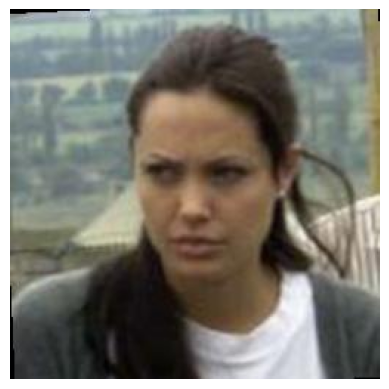

In [78]:
test_image = "../datasets/lfw/Angelina_Jolie/Angelina_Jolie_0016.jpg"
image = cv2.imread(test_image)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

embedding = DeepFace.represent(
    img_path=test_image,
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)[0]["embedding"]

In [79]:
prediction = svm_model.predict([embedding])[0]

predicted_person = label_encoder.inverse_transform([prediction])[0]

print(predicted_person)

Angelina_Jolie


In [80]:
probabilities = svm_model.predict_proba([embedding])[0]

best_index = np.argmax(probabilities)

print("Prediction:", predicted_person)
print("Confidence:", probabilities[best_index] * 100)

Prediction: Angelina_Jolie
Confidence: 22.37748196768367
